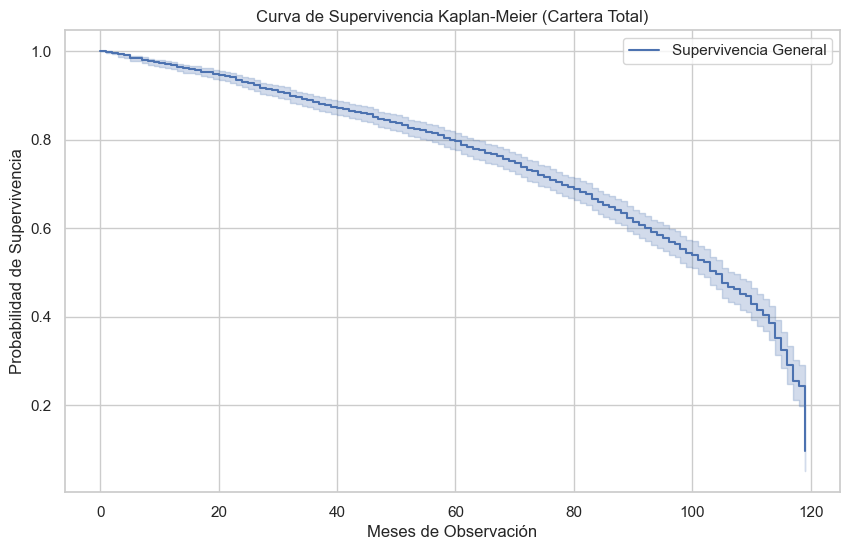

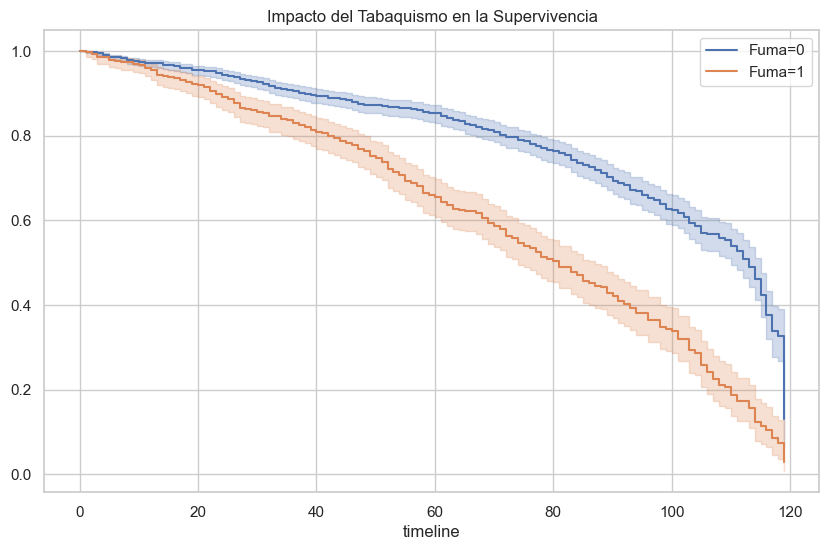


--- Resumen del Modelo Cox ---


<lifelines.CoxPHFitter: fitted with 2000 total observations, 1307 right-censored observations>
             duration col = 'Meses_En_Poliza'
                event col = 'Fallecimiento'
      baseline estimation = breslow
   number of observations = 2000
number of events observed = 693
   partial log-likelihood = -4410.41
         time fit was run = 2026-01-21 17:45:27 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Edad_Inicial            0.03      1.03      0.00            0.02            0.04                1.02                1.04
Genero                 -0.00      1.00      0.08           -0.15            0.15                0.86                1.16
Ingreso_Anual          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Score_Crediticio       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Fuma                    0.94      2.57      0.08            0.79            1.10                2.20                2.99
IMC                     0.05      1.05      0.01            0.04            0.06                1.04                1.07
Ejercicio_Horas_Semana -0.11      0.90      0.01           -0.14           -0.08                0.87                0.92
Hipertension           -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
Diabetes                0.25      1.28      0.11            0.04            0.46                1.04                1.58
Consumo_Alcohol         0.00      1.00      0.05           -0.08            0.09                0.92                1.10
Estres_Laboral         -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
Chequeo_Medico_Anual   -0.03      0.98      0.08           -0.18            0.13                0.84                1.14
Monto_Ahorro_Banca      0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                        cmp to     z      p  -log2(p)
covariate                                            
Edad_Inicial              0.00  8.59 <0.005     56.65
Genero                    0.00 -0.03   0.98      0.03
Ingreso_Anual             0.00 -0.41   0.68      0.55
Score_Crediticio          0.00 -1.41   0.16      2.65
Fuma                      0.00 12.00 <0.005    107.81
IMC                       0.00  6.59 <0.005     34.45
Ejercicio_Horas_Semana    0.00 -7.89 <0.005     48.18
Hipertension              0.00 -1.87   0.06      4.01
Diabetes                  0.00  2.31   0.02      5.57
Consumo_Alcohol           0.00  0.11   0.92      0.13
Estres_Laboral            0.00 -0.23   0.82      0.28
Chequeo_Medico_Anual      0.00 -0.32   0.75      0.42
Monto_Ahorro_Banca        0.00  0.05   0.96      0.06
---
Concordance = 0.70
Partial AIC = 8846.83
log-likelihood ratio test = 312.72 on 13 df
-log2(p) of ll-ratio test = 193.61


--- Clasificación de Riesgo y Probabilidades ---
   ID_Cliente  Edad_Inicial  Fuma  Riesgo_Score  Nivel_Riesgo  Prob_Superv_60m
0           1            63     0      1.637846   Riesgo Alto         0.748136
1           2            53     0      0.844434  Riesgo Medio         0.861048
2           3            39     1      0.955810  Riesgo Medio         0.844224
3           4            32     1      1.993522   Riesgo Alto         0.702448
4           5            45     0      0.518154   Riesgo Bajo         0.912288
5           6            63     1      4.612516   Riesgo Alto         0.441675
6           7            43     0      0.990235  Riesgo Medio         0.839091
7           8            47     0      0.554536   Riesgo Bajo         0.906427
8           9            35     0      0.297664   Riesgo Bajo         0.948631
9          10            35     1      0.812784  Riesgo Medio         0.865890

Concordance Index (C-Index): 0.6962

--- Stress Test: Escenario de Crisis Sanita

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Configuración visual
sns.set(style="whitegrid")
np.random.seed(42)

# =============================================================================
# 1. SIMULACIÓN DE BASE DE DATOS PROFESIONAL (16 VARIABLES)
# =============================================================================
n_clientes = 2000

data = {
    'ID_Cliente': range(1, n_clientes + 1),
    'Edad_Inicial': np.random.randint(25, 65, n_clientes),
    'Genero': np.random.choice(['M', 'F'], n_clientes),
    'Ingreso_Anual': np.random.normal(45000, 15000, n_clientes),
    'Score_Crediticio': np.random.normal(650, 100, n_clientes),
    'Fuma': np.random.choice([0, 1], n_clientes, p=[0.75, 0.25]),
    'IMC': np.random.normal(26, 5, n_clientes),
    'Ejercicio_Horas_Semana': np.random.uniform(0, 10, n_clientes),
    'Hipertension': np.random.choice([0, 1], n_clientes, p=[0.8, 0.2]),
    'Diabetes': np.random.choice([0, 1], n_clientes, p=[0.85, 0.15]),
    'Consumo_Alcohol': np.random.choice([0, 1, 2], n_clientes), # 0:Bajo, 1:Medio, 2:Alto
    'Estres_Laboral': np.random.randint(1, 11, n_clientes),
    'Chequeo_Medico_Anual': np.random.choice([0, 1], n_clientes, p=[0.4, 0.6]),
    'Monto_Ahorro_Banca': np.random.normal(15000, 8000, n_clientes),
    # Variables de Supervivencia (Target)
    'Meses_En_Poliza': np.random.randint(1, 120, n_clientes), # Tiempo (T)
    'Fallecimiento': np.random.choice([0, 1], n_clientes, p=[0.85, 0.15]) # Evento (E)
}

df = pd.DataFrame(data)

# Ajuste lógico: El fallecimiento es más probable si fuma, tiene IMC alto o mayor edad
hazard_base = (df['Edad_Inicial'] * 0.05) + (df['Fuma'] * 1.5) + (df['IMC'] * 0.1) - (df['Ejercicio_Horas_Semana'] * 0.2)
prob_fallecer = 1 / (1 + np.exp(-hazard_base + 5))
df['Fallecimiento'] = np.random.binomial(1, prob_fallecer.clip(0, 1))

# =============================================================================
# 2. EDA (ANÁLISIS EXPLORATORIO)
# =============================================================================
# Curva Kaplan-Meier General
kmf = KaplanMeierFitter()
kmf.fit(df['Meses_En_Poliza'], event_observed=df['Fallecimiento'], label="Supervivencia General")



plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Curva de Supervivencia Kaplan-Meier (Cartera Total)")
plt.xlabel("Meses de Observación")
plt.ylabel("Probabilidad de Supervivencia")
plt.show()

# Comparativa Fuma vs No Fuma
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
for fuma_val in [0, 1]:
    mask = (df['Fuma'] == fuma_val)
    kmf.fit(df['Meses_En_Poliza'][mask], df['Fallecimiento'][mask], label=f"Fuma={fuma_val}")
    kmf.plot_survival_function(ax=ax)
plt.title("Impacto del Tabaquismo en la Supervivencia")
plt.show()

# =============================================================================
# 3. MODELADO (COX PROPORTIONAL HAZARDS)
# =============================================================================
# Preprocesamiento para Cox
df_model = df.drop(columns=['ID_Cliente']).copy()
le = LabelEncoder()
df_model['Genero'] = le.fit_transform(df_model['Genero'])

cph = CoxPHFitter()
cph.fit(df_model, duration_col='Meses_En_Poliza', event_col='Fallecimiento')

print("\n--- Resumen del Modelo Cox ---")
cph.print_summary()

# =============================================================================
# 4. PREDICCIONES Y ANÁLISIS DE RIESGO
# =============================================================================
# Cálculo de Hazard Score (Riesgo Relativo)
df['Riesgo_Score'] = cph.predict_partial_hazard(df_model)

# Clasificación de Riesgo
def clasificar_riesgo(score):
    if score < df['Riesgo_Score'].quantile(0.33): return 'Riesgo Bajo'
    elif score < df['Riesgo_Score'].quantile(0.66): return 'Riesgo Medio'
    else: return 'Riesgo Alto'

df['Nivel_Riesgo'] = df['Riesgo_Score'].apply(clasificar_riesgo)

# Probabilidad de Supervivencia a 60 meses
survival_60 = cph.predict_survival_function(df_model, times=[60]).T
df['Prob_Superv_60m'] = survival_60[60].values

print("\n--- Clasificación de Riesgo y Probabilidades ---")
print(df[['ID_Cliente', 'Edad_Inicial', 'Fuma', 'Riesgo_Score', 'Nivel_Riesgo', 'Prob_Superv_60m']].head(10))

# =============================================================================
# 5. EVALUACIÓN DEL MODELO
# =============================================================================
# C-Index (Métrica clave en supervivencia, similar al AUC)
c_index = concordance_index(df['Meses_En_Poliza'], -df['Riesgo_Score'], df['Fallecimiento'])
print(f"\nConcordance Index (C-Index): {c_index:.4f}")



# =============================================================================
# 6. ANÁLISIS DE SENSIBILIDAD Y STRESS TEST
# =============================================================================
# Stress Test: Escenario de Crisis Sanitaria (Aumento de Riesgo General +20%)
print("\n--- Stress Test: Escenario de Crisis Sanitaria ---")
df_stress = df_model.copy()
df_stress['IMC'] *= 1.15 # Aumento de obesidad promedio
df_stress['Estres_Laboral'] += 2 # Aumento de estrés

# Predecir impacto en la probabilidad de supervivencia promedio a 5 años
prob_base = cph.predict_survival_function(df_model, times=[60]).mean(axis=1).values[0]
prob_stress = cph.predict_survival_function(df_stress, times=[60]).mean(axis=1).values[0]

print(f"Prob. Supervivencia promedio (Base) a 60m: {prob_base:.2%}")
print(f"Prob. Supervivencia promedio (Stress) a 60m: {prob_stress:.2%}")
print(f"Impacto en Longevidad Proyectada: {((prob_stress/prob_base)-1)*100:.2f}%")

#